# Propagation d'un paquet d'onde
Objectif : on souhaite étudier la propagation d'une onde au cours du temps.
On suppose connue l'amplitude de l'onde à l'instant initial $t=0$ : $s(x,0)$.

$s(x,t)$ est solution d'une équation qui n'est pas l'équation de D'Alembert : il faut la réécrire sous forme de somme de pseudo-OPPH pour savoir comment elle se propage. On décompose donc $s(x,0)$ en série de Fourier. Habituellement, nous décomposons une fonction du temps pour obtenir le spectre en fonction de la pulsation temporelle $\omega$. Ici, il s'agit d'une fonction de $x$ : le principe est le même, mais on décompose par rapport à la pulsation spatiale $k$ :
$$s(x,0)=\sum_k \underline{F_0}(k)\;\mathrm{exp}(jkx) $$

Le but de cette capacité numérique est d'étudier la propagation d'un paquet d'onde. Nous l'avons défini dans le cours comme une somme d'OPPH de pulsations proches (pulsation temporelle dans le cours, mais comme $\omega$ et $k$ sont reliés par la relation de dispersion, il est équivalent de considérer que c'est une somme d'OPPH de pulsation spatiale $k$). 
Par commodité, nous partirons de la donnée du spectre $\underline{F_0}(k)$ plutôt que de la donnée de $s(x,0)$. L'avantage est qu'il n'y a pas besoin de faire les calculs permettant de trouver $\underline{F_0}(k)$ connaissant $s(x,0)$ (surtout qu'on ne sait pas comment faire ces calculs...). L'inconvénient est que l'on ne sait pas quelle onde on est en train d'étudier, et il va donc falloir commencer par déterminer l'allure de $s(x,0)$.

Pour étudier la propagation de cette onde, nous allons dans un premier temps chercher à tracer la fonction $s(x,0)$ (pour savoir quelle onde on étudie : il n'est pas facile de le voir directement à partir du spectre).

Dans un deuxième temps, nous chercherons à déterminer l'expression de $s(x,t)$ pour pouvoir tracer l'évolution de l'onde au cours du temps.

## Déclaration des modules utilisés

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft

## Création de l'onde initiale

Choisissons donc la fonction qui va décrire le spectre de l'onde à $t=0$. On souhaite une fonction qui représente des composantes réparties autour de $k_0$ avec une largeur caractéristique $\Delta k$ autour de cette valeur : la gaussienne (que l'on retrouve souvent en physique) correspond très bien à ce besoin :

$$ \underline{F_0}(k)=A\;\mathrm{exp}\left(-\left(\frac{k-k_0}{\Delta k}\right)^2\right)$$

Par commodité, prenons $A=1$.

$\Delta k$ désigne la largeur du paquet d'onde, et $k_0$ la valeur moyenne. Si on veut un paquet d'onde très piqué, on prendra donc $\Delta k \ll k_0$.

On crée donc les deux listes k et F0 : F0[i] contient l'amplitude de la composante de Fourier à la pulsation k[i].

On trace ensuite F0 pour vérifier l'allure du spectre utilisé.

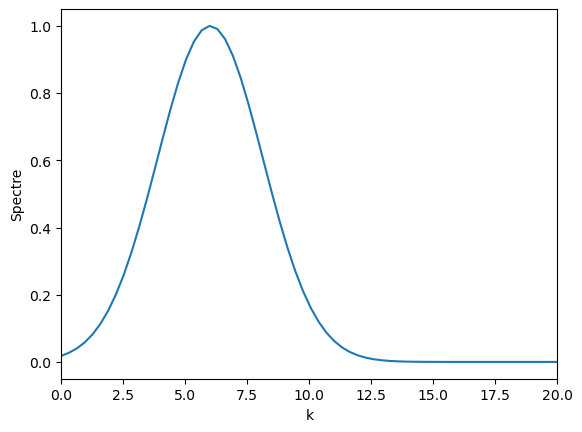

In [32]:
N=2**12 #Le nombre de points doit être une puissance de 2 pour le calcul de la transformée de Fourier
xmin = -10
xmax = 10
X = np.linspace(xmin, xmax, N)
L = xmax-xmin #Longueur de l'intervalle
k=np.linspace(0,2*np.pi*N/L,N)

k0 = 6
deltak = 3
F0 = [np.exp(-((k[i]-k0)/deltak)**2) for i in range(N)]

# Tracé du spectre
plt.figure() #on ouvre une nouvelle fenêtre
plt.plot(k, np.abs(F0))
plt.xlim([0,20])
plt.xlabel('k')
plt.ylabel('Spectre')
plt.show()
plt.close()

## Représentation de $s(x,0)$
Pour savoir quelle onde nous étudions, il faut représenter $s(x,0)$.

Pour cela, il suffit de sommer, pour chaque valeur de $x$, les contributions de toutes les composantes de Fourier. Il faut donc faire une double boucle for : sur toutes les valeurs de $x$ et sur toutes les valeurs de $k$.

In [4]:
def fourierInverse(k, X, F):
    sortie = []
    for i in range(len(X)):
        somme = 0
        for j in range(len(k)):
            somme += F[j] * np.exp(1j * k[j] * X[i])
        sortie.append(somme)
    return sortie
 
IF = fourierInverse(k, X, F0)
plt.figure()
plt.plot(X, np.real(IF))
plt.ylabel('Amplitude')
plt.xlabel('x')
plt.show()
plt.close()

KeyboardInterrupt: 

Ce script est très long ! Cela est dû au fait que Python est un langage interprété, la double boucle for implique une complexité en $N^2$.

Pour gagner (beaucoup !) de temps, on peut utiliser les tableaux numpy pour éviter une boucle for :

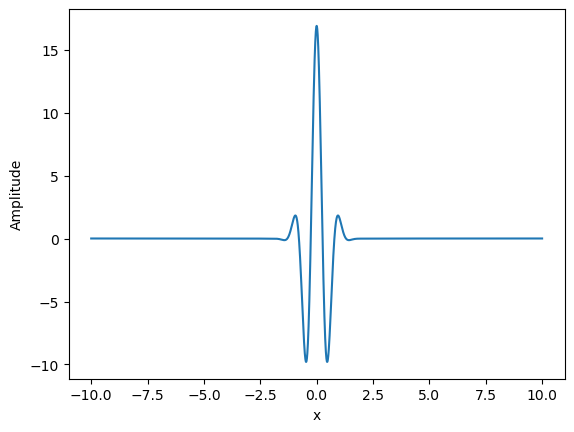

In [33]:
def fourierInverseNumpy(k, X, F):
    sortie = np.zeros(len(X), dtype=np.complex_)
    for i in range(len(k)):
        sortie += np.array(F[i]) * np.exp(1j * k[i] * X)
    return sortie
 
IF = fourierInverseNumpy(k, X, F0)
plt.figure()
plt.plot(X, np.real(IF))
plt.ylabel('Amplitude')
plt.xlabel('x')
plt.show()
plt.close()

a = np.array(F0) * np.exp(1j * k * X[0])

Ou alternativement... Il y a évidemment une fonction déjà implémentée en Python qui fait ce même calcul (à une constante multiplicative près) : le module ifft de numpy. Nous utiliserons celui-ci dans la suite car il est plus rapide, mais on gardera en mémoire que le principe est celui de la fonction fourierInverse() écrite ci-dessus.

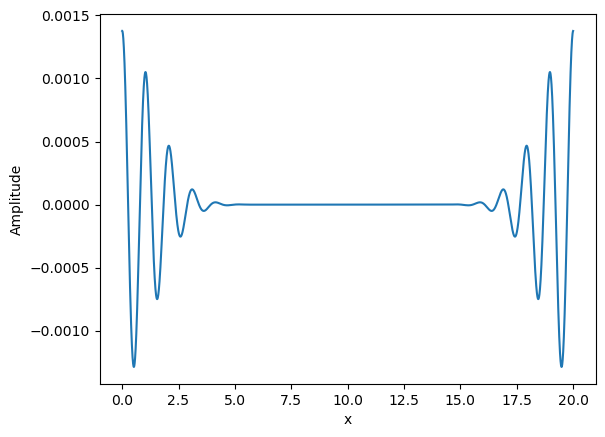

In [6]:
# Tracé du signal temporel : on fait la FFT inverse
IF = ifft(F0)
plt.figure()
plt.plot(X, np.real(IF))
plt.ylabel('Amplitude')
plt.xlabel('x')
plt.show()
plt.close()

Ce signal temporel peut sembler étrange au premier abord, mais il ne faut pas oublier que le FFT est destinée à étudier des courbes périodiques. La partie à droite peut être recopiée à gauche : elle est identique dans la période précédente. 

On fabrique alors une fonction qui nous permet de recopier la deuxième moitié de la courbe à gauche :

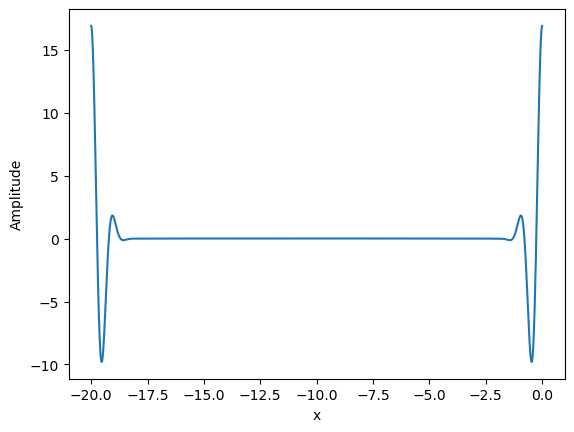

In [34]:
def decaler_moitiee(courbe):
    sortie=[]
    for i in range(len(courbe)//2):
        sortie.append(courbe[len(courbe)//2 + i])
    for i in range(len(courbe)//2):
        sortie.append(courbe[i])
    return sortie

Xd = np.linspace(xmin - L/2, xmax-L/2, N)


plt.figure()
plt.plot(Xd, decaler_moitiee(np.real(IF)))
plt.ylabel('Amplitude')
plt.xlabel('x')
plt.show()
plt.close()

Alternativement, on aurait également pu décaler la courbe vers la droite. Pour cela, il suffit de faire un changement de variable sur la courbe initiale, pour changer l'ordonnée selon $x$ : $x' \rightarrow x - x0$.
Alors :
$$s(x',0)=\sum_k \underline{F_0}(k)\;\mathrm{exp}(jkx') = \sum_k \underline{F_0}(k)\;\mathrm{exp}(-jkx0)\;\mathrm{exp}(jkx) $$
Il suffit donc de multiplier chaque composante du spectre de Fourier précédent par $\mathrm{exp}(-jkx0)$ (en le faisant bien pour chaque composante, puisque la valeur de $k$ est différente pour chacune d'elle). On obtient alors le même signal que celui du dessus, mais centré en x0.

## Propagation de l'onde qui se propage selon $+\overrightarrow{u_x}$ pendant t
Pour obtenir l'expression de $s(x,t)$, il faut regarder le devenir de chacune des OPPH qui vaut à t=0 : $\underline{F_0(k)}\;\exp(j k x)$. Choisissons d'étudier l'onde qui se propage selon $+\overrightarrow{u_x}$. On reconnaît alors dans l'expression de l'OPPH à $t=0$ le cas particulier de l'OPPH : $\underline{F_0}(k)\;\exp(j (k x - \omega t))$
(on pourrait de même étudier l'onde qui se propage selon $-\overrightarrow{u_x}$ en choisissant $\underline{F_0}(k)\;\exp(j (k x + \omega t))$). 


L'onde résultante $s(x,t)$ est obtenue par somme de toutes ces OPPH :
$$s(x,t)=\sum_k \underline{F_0}(k)\;\exp(j (k x - \omega t))$$

On réécrit cette expression pour la faire apparaître comme une série de Fourier :
$$s(x,t)=\sum_k \underline{F_0}(k)\;\mathrm{exp}(-j \omega t)\;\mathrm{exp}(jkx) $$

Chaque composante de Fourier a donc pour amplitude $\underline{F_0}(k)\;\mathrm{exp}(-j \omega t)$. On multiplie donc l'amplitude de chaque composante de Fourier de l'onde initiale par $\mathrm{exp}(-i \omega t)$ pour traduire sa propagation pendant t.

Attention : comme $k$ varie pour chaque composante de Fourier, $\omega$ varie également et est donnée par la relation de dispersion.

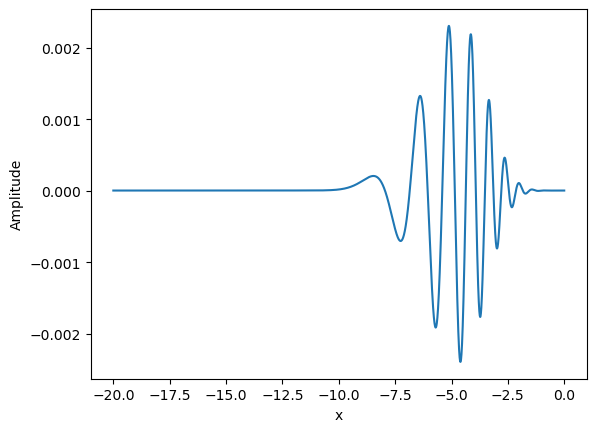

In [38]:
def omega(k):
    '''Relation de dispersion'''
    # omegap eleve : omegap = 6
    # omegap faible : omegap = 0.1
    omegap = 10
    c = 1
    o = (k**2*c**2+omegap**2)**0.5        
    return o

def spectrePropagee(t):
    '''Calcul des composantes de Fourier après une propogation pendant une durée t'''
    Ft = [] #Liste des amplitudes des composantes de Fourier de l'onde après une durée de propagation t
    for i in range(N):
        composante = F0[i] * np.exp(-1j * omega(k[i]) * t)
        Ft.append(composante)
    return Ft
        
# Tracé du signal temporel : on fait la FFT inverse
t = 10 #Durée de la propagation
IF = ifft(spectrePropagee(t))
plt.figure()
plt.plot(Xd, decaler_moitiee(np.real(IF)))
plt.ylabel('Amplitude')
plt.xlabel('x')
plt.show()
plt.close()

## Animation
Pour rendre les choses plus visuelles, on peut recommencer pour plusieurs intervalles de temps différents. Python permet de faire cela avec le module animation de matplotlib. Ce module n'est pas au programme : il est donné ici pour mieux visualiser la propagation mais n'est pas à connaître (et il ne marche pas sur tous les interpréteurs Python...).

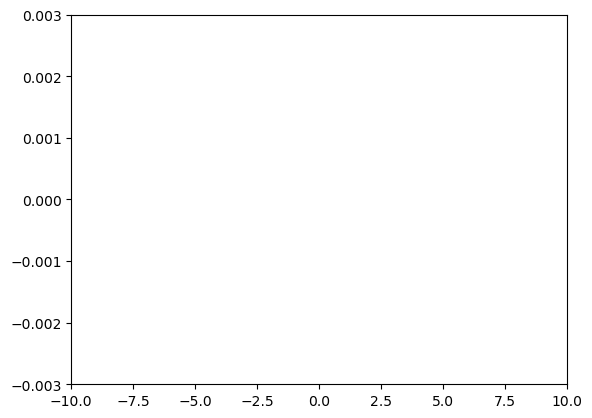

In [18]:
## Animation
from matplotlib import animation

fig = plt.figure() # initialise la figure
line, = plt.plot([],[]) 
plt.xlim(xmin-L/2, xmax-L/2)
plt.ylim(-3e-3,3e-3)

# fonction à définir quand blit=True
# crée l'arrière de l'animation qui sera présent sur chaque image
def init():
    line.set_data([],[])
    return line,
    
def animate(i): 
    IF = ifft(spectrePropagee(i/5))
    line.set_data(Xd, decaler_moitiee(np.real(IF)))
    return line,
    
ani = animation.FuncAnimation(fig, animate, init_func=init, frames=50, blit=True, interval=100, repeat=False)

plt.show()

Remarque : on peut tester les jeux de valeurs différents : 
<ul>
<li>deltak 1, omegap = 6
<li>deltak 1, omegap = 0.1
<li>deltak 3, omegap = 6

Si on augmente le temps de propagation de l'onde, on voit qu'elle réapparait par la gauche. Cela est dû au fait que le développement en série de Fourier étudie des fonctions périodiques : si la courbe continue à droite en dehors de la plage d'étude, la période précédente apparaît à gauche.
